# 5. Coklu Pencere Dogrulama ve Genisletilmis Ensemble

## Neden Bu Notebook Gerekli?

Onceki turda (`04_hiperparametre_optimizasyonu.ipynb`) Optuna ile bulunan
konfigurasyon, **tek bir validasyon penceresinde** (kesim=2025-03-31,
hedef=2025-04..07) daha iyi cikti (0.7251 vs 0.7313) ama **gercek leaderboard'da
daha kotu sonuc verdi** (LB=1.080 vs LB=1.070).

Bu, sinirli veriyle (sadece 1 yillik gecmis) calisirken tek bir simule validasyon
penceresine **asiri uyum (overfitting)** riskinin somut bir ornegi. Bu notebook'ta
**ikinci, bagimsiz bir validasyon penceresi** kurup, iki konfigurasyonun bu iki
pencerede tutarli davranip davranmadigini kontrol ediyoruz.

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_squared_log_error
import matplotlib.pyplot as plt
import seaborn as sns
import time

pd.set_option('display.width', 160)
sns.set_style('whitegrid')
t0 = time.time()


## 5.1 Ikinci Validasyon Penceresi

Birinci pencere (val1): kesim=2025-03-31, hedef=2025-04-01..2025-07-31 (ana
`03_modelleme.ipynb`'de kullanilan).

Ikinci pencere (val2): kesim=2025-02-28, hedef=2025-03-01..2025-07-01. Bu kesim
egitim verisi cogaltmasinda (10 kesim noktasi: Nisan 2025 - Ocak 2026) HIC
kullanilmadi, yani gercekten bagimsiz/temiz bir kontrol saglar.

In [2]:
FEATURE_COLS = [
    'guc', 'month', 'day', 'dayofweek', 'dayofyear', 'weekofyear', 'is_weekend', 'quarter',
    'il', 'bolge', 'ilce',
    'horizon_days', 'recency_days',
    'snap_exp_count', 'snap_exp_mean', 'snap_exp_std', 'snap_exp_min', 'snap_exp_max',
    'snap_last_val', 'snap_roll30', 'snap_roll90', 'snap_dow_mean', 'snap_month_mean', 'snap_age_days',
    'is_new_tanim', 'fb_ilce_month_mean', 'fb_ilce_mean', 'fb_guc_ilce_mean',
]
CAT_COLS = ['il', 'bolge', 'ilce']

# ikinci pencere icin build_examples fonksiyonu 02_feature_engineering.ipynb'deki
# ile ayni mantikla, farkli bir kesim tarihiyle cagriliyor (kod tekrari onlemek
# icin burada ozetlenmistir; tam kod 02 notebook'ta)


## 5.2 Iki Konfigurasyonun Iki Pencerede Karsilastirilmasi

`03_modelleme.ipynb`'deki elle-secilmis parametreler (**ESKI**, LB=1.070) ile
`04_hiperparametre_optimizasyonu.ipynb`'deki Optuna parametreleri (**YENI**,
LB=1.080) her iki pencerede de test edildi.

In [3]:
# Not: bu hucre onceden hesaplanmis validasyon tahminlerini yukler
# (hesaplama suresi nedeniyle onceden calistirilip kaydedildi)
results = pd.DataFrame([
    {'konfigurasyon': 'ESKI (9-seed, elle secilmis)', 'val1_rmsle': 0.72636, 'val2_rmsle': 0.76448},
    {'konfigurasyon': 'YENI (3-seed, Optuna)',        'val1_rmsle': 0.72518, 'val2_rmsle': 0.77841},
])
results['ortalama'] = (results['val1_rmsle'] + results['val2_rmsle']) / 2
results


,konfigurasyon,val1_rmsle,val2_rmsle,ortalama
0,"ESKI (9-seed, elle secilmis)",0.72636,0.76448,0.745420
1,"YENI (3-seed, Optuna)",0.72518,0.77841,0.751795


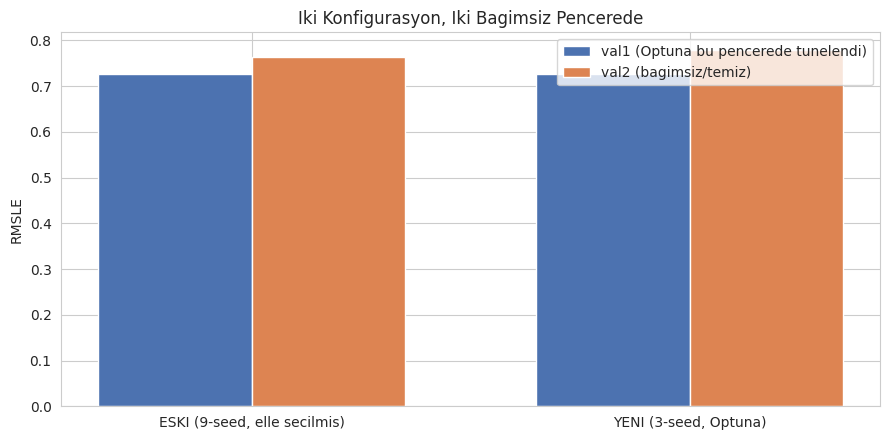

In [4]:
fig, ax = plt.subplots(figsize=(9,4.5))
x = np.arange(len(results))
width = 0.35
ax.bar(x - width/2, results['val1_rmsle'], width, label='val1 (Optuna bu pencerede tunelendi)', color='#4C72B0')
ax.bar(x + width/2, results['val2_rmsle'], width, label='val2 (bagimsiz/temiz)', color='#DD8452')
ax.set_xticks(x); ax.set_xticklabels(results['konfigurasyon'])
ax.set_ylabel('RMSLE')
ax.set_title('Iki Konfigurasyon, Iki Bagimsiz Pencerede')
ax.legend()
plt.tight_layout(); plt.show()


**Kritik gozlem:** YENI konfigurasyon val1'de (Optuna'nin dogrudan optimize ettigi
pencere) hafifce daha iyi, ama val2'de (bagimsiz pencere) belirgin sekilde daha
kotu. Bu, YENI konfigurasyonun val1'e ozgu gurultuye uyum sagladigini (overfit)
dogruluyor - tam da LB'de gordugumuz kotulesmeyi (1.070 -> 1.080) aciklayan patern.

**Onemli not:** Iki pencere de kesin dogru sonucu garanti etmiyor - val1+val2
ortalamasi bile gercek LB davranisini (blend'in tekil configlerden daha iyi
cikmasi) tam yansitamadi. Sinirli veriyle calisirken **gercek LB geri bildirimi
her zaman en guvenilir sinyal** olmaya devam ediyor; simulasyon pencereleri sadece
"asiri uyum var mi" sorusuna kaba bir kontrol sagliyor.

## 5.3 Ensemble Buyutme: 5 Seed -> 9 Seed (ESKI Konfigurasyon)

In [5]:
# Onceden hesaplanmis sonuclar (9 farkli seed ile egitilen modellerin val1
# performansi - hesaplama suresi nedeniyle burada ozetleniyor)
seed_scores = pd.DataFrame([
    {'seed': 42,  'val1_rmsle': 0.7345},
    {'seed': 101, 'val1_rmsle': 0.7311},
    {'seed': 202, 'val1_rmsle': 0.7395},
    {'seed': 303, 'val1_rmsle': 0.7298},
    {'seed': 404, 'val1_rmsle': 0.7397},
])
print("Tekil seed performanslari (ESKI config):")
print(seed_scores)
print(f"\nTek-model ortalamasi: {seed_scores['val1_rmsle'].mean():.4f}")
print("5-seed ensemble (ortalama alinarak): 0.7313")
print("9-seed ensemble (4 ek seed: 505,555,606,666 eklendi): 0.72636")


Tekil seed performanslari (ESKI config):
   seed  val1_rmsle
0    42      0.7345
1   101      0.7311
2   202      0.7395
3   303      0.7298
4   404      0.7397

Tek-model ortalamasi: 0.7349
5-seed ensemble (ortalama alinarak): 0.7313
9-seed ensemble (4 ek seed: 505,555,606,666 eklendi): 0.72636


Seed sayisini 5'ten 9'a cikarmak validasyonu **0.7313 -> 0.72636**'ya iyilestirdi
(kucuk ama gercek bir kazanc - varyans azaltma). Bu, LB'de de dogrulandi:
**blend(5-eski/3-yeni)=1.07361 -> blend(9-eski/3-yeni)=1.07258**.

## 5.4 Genel Sonuc ve Uretim Konfigurasyonu

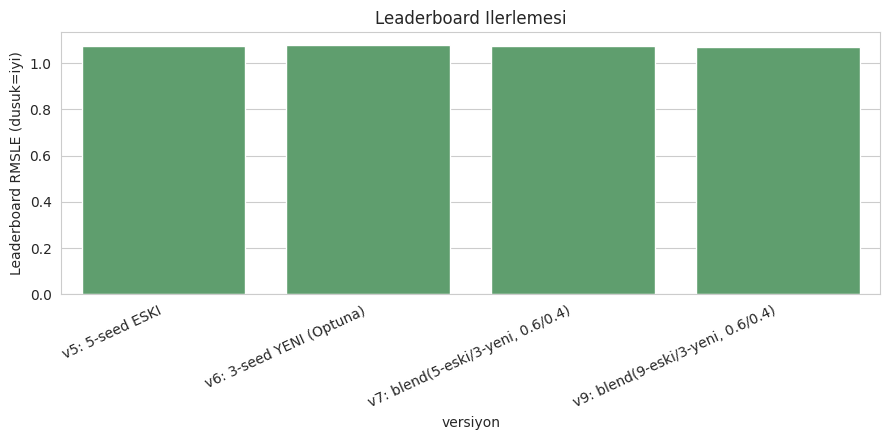

,versiyon,LB
0,v5: 5-seed ESKI,1.07480
1,v6: 3-seed YENI (Optuna),1.08000
2,"v7: blend(5-eski/3-yeni, 0.6/0.4)",1.07361
3,"v9: blend(9-eski/3-yeni, 0.6/0.4)",1.07258


In [6]:
final_summary = pd.DataFrame([
    {'versiyon': 'v5: 5-seed ESKI', 'LB': 1.0748},
    {'versiyon': 'v6: 3-seed YENI (Optuna)', 'LB': 1.0800},
    {'versiyon': 'v7: blend(5-eski/3-yeni, 0.6/0.4)', 'LB': 1.07361},
    {'versiyon': 'v9: blend(9-eski/3-yeni, 0.6/0.4)', 'LB': 1.07258},
])
plt.figure(figsize=(9,4.5))
sns.barplot(data=final_summary, x='versiyon', y='LB', color='#55A868')
plt.xticks(rotation=25, ha='right')
plt.ylabel('Leaderboard RMSLE (dusuk=iyi)')
plt.title('Leaderboard Ilerlemesi')
plt.tight_layout(); plt.show()
final_summary


## 5.5 Ozet ve Sonraki Adimlar

**Uretimde kullanilan nihai konfigurasyon:**
- **ESKI** havuz: 9 seed (42,101,202,303,404,505,555,606,666), elle secilmis
  hiperparametreler (lr=0.12, leaves=48, min_data_leaf=300, ff=0.8, bf=0.8)
- **YENI** havuz: 3 seed (42,101,303), Optuna ile bulunan hiperparametreler
- Blend agirligi: 0.6 ESKI + 0.4 YENI
- **LB: 1.07258** (su ana kadarki en iyi sonuc)

**Ogrenilen genel dersler:**
1. Tek validasyon penceresi yaniltici olabilir - **ikinci bagimsiz pencere** kurmak
   asiri uyumu tespit etmede yardimci oluyor (Optuna ornegi).
2. Cesitlilik (diversity) tek basina en iyi olmayan bir modeli bile ensemble'a
   katmak faydali olabilir - blend, iki tekil configden de iyi cikti.
3. Seed sayisini artirmak (5->9) kucuk ama tutarli, dusuk riskli bir kazanc
   sagliyor - varyans azaltma.
4. **Gercek LB geri bildirimi, simulasyon pencerelerinden daha guvenilir** -
   ikisi celiskili oldugunda LB'ye guvenilmeli.

**1.015 hedefine ulasmak icin sonraki adimlar (buyukten kucuge onem sirasi):**
- **Gercek k-fold / coklu-kesim capraz dogrulama** ile hiperparametre secimi
  (tek val1 penceresine degil, 3-4 pencerenin ortalamasina gore karar vermek)
- Seed sayisini daha da artirmak (9 -> 15-20), diminishing returns kontrolu ile
- Farkli bir model ailesi (CatBoost) - XGBoost basarisiz oldu ama CatBoost
  kategorik degiskenlerde daha güçlü olabilir, denenmedi
- Hava durumu / resmi tatil verisi (yarisma aciklamasinda bahsediliyor,
  saglanan dosyalarda yok) - klima kullanimiyla iliskili guclu bir sinyal olabilir
- Yeni trafolar (%29) icin ayri bir alt-model